In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [2]:
from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize, poly)

In [3]:
from statsmodels.stats.anova import anova_lm

In [4]:
CarSeats = load_data("Carseats")
CarSeats

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...
395,12.57,138,108,17,203,128,Good,33,14,Yes,Yes
396,6.14,139,23,3,37,120,Medium,55,11,No,Yes
397,7.41,162,26,12,368,159,Medium,40,18,Yes,Yes
398,5.94,100,79,7,284,95,Bad,50,12,Yes,Yes


In [5]:
X = MS(["Price", "Urban", "US"]).fit_transform(CarSeats)
X

,intercept,Price,Urban[Yes],US[Yes]
0,1.0,120,1.0,1.0
1,1.0,83,1.0,1.0
2,1.0,80,1.0,1.0
3,1.0,97,1.0,1.0
4,1.0,128,1.0,0.0
...,...,...,...,...
395,1.0,128,1.0,1.0
396,1.0,120,0.0,1.0
397,1.0,159,1.0,1.0
398,1.0,95,1.0,1.0


In [6]:
y = CarSeats["Sales"]
y

0       9.50
1      11.22
2      10.06
3       7.40
4       4.15
       ...  
395    12.57
396     6.14
397     7.41
398     5.94
399     9.71
Name: Sales, Length: 400, dtype: float64

In [7]:
model = sm.OLS(y, X)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,13.0435,0.651,20.036,0.000
Price,-0.0545,0.005,-10.389,0.000
Urban[Yes],-0.0219,0.272,-0.081,0.936
US[Yes],1.2006,0.259,4.635,0.000


(b) Interpretation of Coefficient
intercept : represent the Constant value of sales irrelevant of Price, Urban, US values
Price : How does the price change affect the sale, more mathematically keeping other variables constant for unit price increase how much increase (or decrease) in sales.)
Urban : Average amount extra (or less) sales for a urban compared to not urban
US : similar to urban.

(c) Answered in Notebook

(d) We can reject null Hypothesis for intercept, price and us. On the other hand we can't reject null hypothesis for Urban because p value is very large.

In [8]:
X = MS(["Price", "US"]).fit_transform(CarSeats)
model2 = sm.OLS(y, X)
results2 = model2.fit()
summarize(results2)

,coef,std err,t,P>|t|
intercept,13.0308,0.631,20.652,0.0
Price,-0.0545,0.005,-10.416,0.0
US[Yes],1.1996,0.258,4.641,0.0


In [9]:
anova_lm(results, results2)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,396.0,2420.834671,0.0,NaN,NaN,NaN
1,397.0,2420.874462,-1.0,-0.03979,0.006525,NaN


In [16]:
results2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     62.43
Date:                Tue, 25 Nov 2025   Prob (F-statistic):           2.66e-24
Time:                        11:16:09   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1861.
Df Residuals:                     397   BIC:                             1873.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     13.0308      0.631     20.652      0.000      11.790      14.271
Price         -0.0545      0.005    -10.416      0.000      -0.065      -0.044
US[Yes]        1.1996      0.258      4.641      0.000       0.692       1.708
==============================================================================
Omnibus:                        0.666   Durbin-Watson:                   1.912
Prob(Omnibus):                  0.717   Jarque-Bera (JB):                0.749
Skew:                           0.092   Prob(JB):                        0.688
Kurtosis:                       2.895   Cond. No.                         607.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [19]:
results2.conf_int(alpha = 0.05)

,0,1
intercept,11.79032,14.271265
Price,-0.06476,-0.044195
US[Yes],0.69152,1.707766


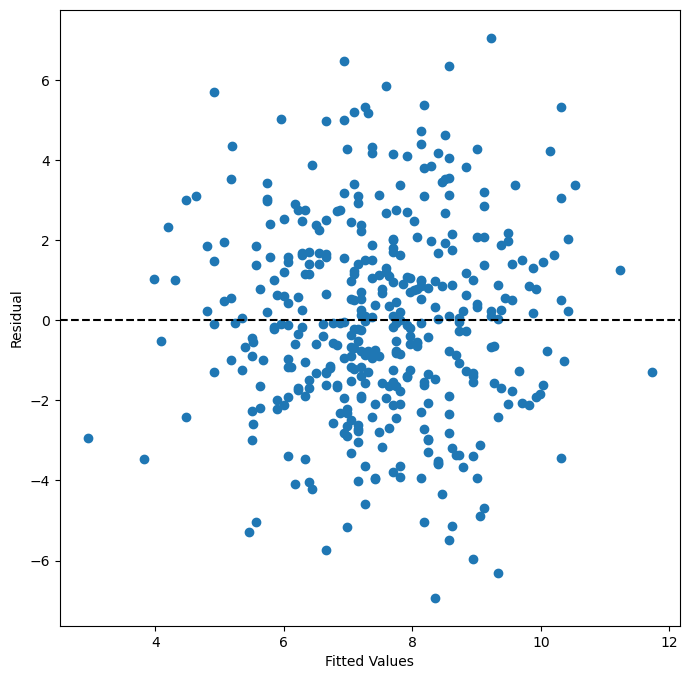

In [24]:
fig, ax = plt.subplots(figsize = (8, 8))
ax.scatter(results2.fittedvalues, results2.resid)
ax.set_ylabel("Residual")
ax.set_xlabel("Fitted Values")
ax.axhline(0, c='k', ls='--')

Based on the residual plot, there is little to no evidence of non linearity in the data.

np.int64(42)

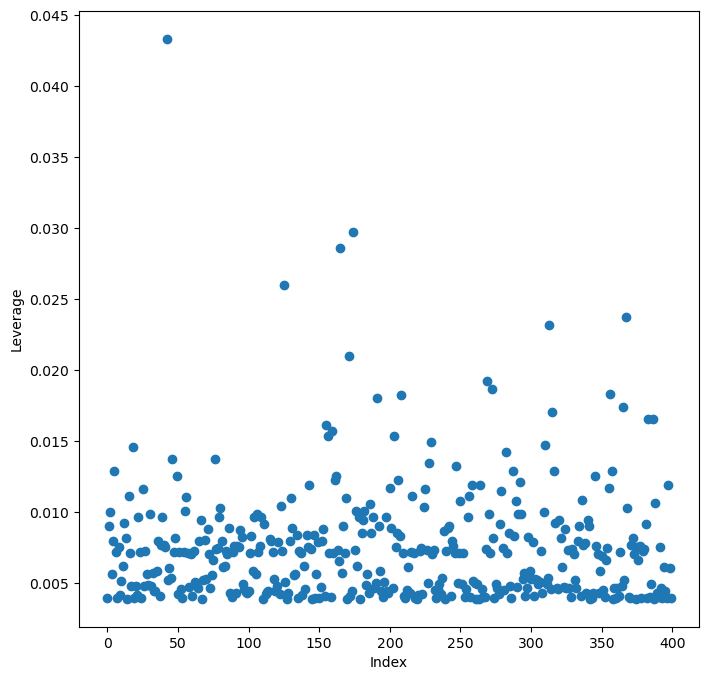

In [26]:
infl = results2.get_influence()
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)

In [29]:
p = 3
n = 400
print(f'The average value of the leverage statistic is {(p+1)/n}')

The average value of the leverage statistic is 0.01


In [32]:
infl.summary_frame()

,dfb_intercept,dfb_Price,dfb_US[Yes],cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits
0,-0.004685,0.004960,0.026900,0.000705,0.733148,0.003922,0.046002,0.732720,0.045975
1,0.041735,-0.044186,0.025407,0.001145,0.614748,0.009004,0.058597,0.614266,0.058551
2,0.005649,-0.005980,0.003187,0.000020,0.076422,0.009954,0.007663,0.076326,0.007653
3,-0.024934,0.026398,-0.024827,0.000745,-0.627878,0.005636,-0.047272,-0.627399,-0.047236
4,0.000424,-0.023159,0.053707,0.001602,-0.775599,0.007928,-0.069333,-0.775210,-0.069298
...,...,...,...,...,...,...,...,...,...
395,-0.048599,0.051453,0.077420,0.006908,2.156206,0.004438,0.143957,2.166210,0.144625
396,0.004026,-0.004263,-0.023118,0.000521,-0.630184,0.003922,-0.039541,-0.629705,-0.039511
397,-0.063661,0.067399,0.024032,0.002252,0.750194,0.011861,0.082190,0.749780,0.082145
398,-0.055414,0.058668,-0.050427,0.003226,-1.265274,0.006010,-0.098384,-1.266235,-0.098458
